# Projeto 3 — Interpolação e Regressão Polinomial
Este notebook implementa os conceitos da questão 1 para as questões 2 e 3 do Projeto 3 em Julia.
Ele mostra a matriz de avaliação em base canônica (Vandermonde), a base de Lagrange, e a matriz de regressão por mínimos quadrados.

## 1. Funções auxiliares
Definimos a matriz de Vandermonde para a base canônica e uma função para construir a matriz de avaliação na base de Lagrange.

In [9]:
using LinearAlgebra
using Plots

function vandermonde(x::Vector{Float64}, d::Integer)
    m = length(x)
    V = zeros(Float64, m, d + 1)
    for i in 1:m, j in 1:d + 1
        V[i, j] = x[i]^(j - 1)
    end
    return V
end

function least_squares_matrix(A::AbstractMatrix{Float64})
    # A é a matriz de avaliação L_X em alguma base de P_d.
    # A solução dos mínimos quadrados seria p = R_X,d * b, onde R_X,d = pinv(A).
    return pinv(A)
end

function lagrange_basis(nodes::Vector{Float64})
    n = length(nodes)
    basis = Vector{Function}(undef, n)
    for i in 1:n
        xi = nodes[i]
        denom = prod(xi - nodes[j] for j in 1:n if j != i)
        basis[i] = x -> begin
            num = prod(x - nodes[j] for j in 1:n if j != i)
            return num / denom
        end
    end
    return basis
end

function lagrange_eval_matrix(X::Vector{Float64}, nodes::Vector{Float64})
    basis = lagrange_basis(nodes)
    m = length(X)
    k = length(nodes)
    M = zeros(Float64, m, k)
    for i in 1:m, j in 1:k
        M[i, j] = basis[j](X[i])
    end
    return M
end

lagrange_eval_matrix (generic function with 1 method)

## 2. Montando as matrizes de avaliação e regressão
Aqui simulamos um conjunto de pontos distintos `X` e construímos as matrizes `L_X` e `R_X,d` em duas bases diferentes.

In [10]:
X = collect(range(-1.0, 1.0, length = 200))
d = 10
A = vandermonde(X, d)
R = least_squares_matrix(A)
println("Matriz L_X em base canônica (Vandermonde): tamanho = ", size(A))
println("Matriz R_X,d em base canônica: tamanho = ", size(R))
println("cond(L_X) = ", cond(A))
println("cond(R_X,d) = ", cond(R))

Matriz L_X em base canônica (Vandermonde): tamanho = (200, 11)
Matriz R_X,d em base canônica: tamanho = (11, 200)
cond(L_X) = 2988.1042180993554
cond(R_X,d) = 2988.1042180994978


## 3. Base de Lagrange
Construímos a base de Lagrange usando os primeiros `d+1` pontos de `X`.

In [11]:
nodes = collect(range(-1.0, 1.0, length = d + 1))
A_lagr = lagrange_eval_matrix(X, nodes)
R_lagr = least_squares_matrix(A_lagr)
println("Matriz L_X em base de Lagrange: tamanho = ", size(A_lagr))
println("cond(L_X) em Lagrange = ", cond(A_lagr))
println("cond(R_X,d) em Lagrange = ", cond(R_lagr))

Matriz L_X em base de Lagrange: tamanho = (200, 11)
cond(L_X) em Lagrange = 34.412728885431044
cond(R_X,d) em Lagrange = 34.41272888543106


## 4. Teste com um vetor de dados
A melhor forma de ver o efeito do condicionamento é aplicar as matrizes a um vetor de observações.

In [12]:
b = sin.(2π .* X) .+ 0.1 .* randn(length(X))
p_mono = R * b
p_lagr = R_lagr * b
println("Erro residual usando base canônica: ", norm(A * p_mono - b))
println("Erro residual usando base de Lagrange: ", norm(A_lagr * p_lagr - b))

Erro residual usando base canônica: 1.3913268419131937
Erro residual usando base de Lagrange: 1.3913268419131932


## 5. Interpretação e próximos passos
- `L_X` em base canônica é a matriz de Vandermonde.
- `R_X,d` é a pseudo-inversa de `L_X`, que representa a regressão de mínimos quadrados.
- A base de Lagrange muda a forma de `L_X`, e isso pode afetar o condicionamento.

### Para avançar
1. Varie `m` e `d` e veja como `cond(A)` e `cond(R)` mudam.
2. Compare o comportamento usando `X` equiespaçados e `X` de Chebyshev.
3. Adicione um gráfico com `Plots` para mostrar o crescimento do condicionamento com `d`.

# Questão 2
### (a)
Tome $q \in \mathcal{P}_d$ qualquer. Daí,


$$R_{X,d}(L_X(q)) = \arg\min_{p \in \mathcal{P}_d} ||L_X(p) - L_X(q)||_2^2$$

É fato que para $p = q \implies ||L_X(p) - L_X(q)||_2^2 = 0$. Para garantir que $R_{X,d}(L_X(q)) = q$, e que $q$ é o único que satisfaz $\arg\min_{p \in \mathcal{P}_d} ||L_X(p) - L_X(q)||_2^2 = 0$, verificamos que $L_X$ é injetora, ou seja, $L_X(p) = L_X(q) \implies p = q$.

Para tal, vamos mostrar que $\dim(\mathcal{N}(L_X)) = 0$. Suponha $p \in \mathcal{N}(L_X)$. Então $L_X(p) = (0, \dots, 0)$, ou seja, $p(x_i) = 0$ para todo $x_i \in X$.

Como $p$ tem grau no máximo $d$, $p$ deve possuir no máximo $d$ raízes. Mas $p(x) = 0$ para $m > d$ diferentes valores de $x$, logo, $p$ só pode ser o polinômio identicamente nulo. Ou seja, $\dim(\mathcal{N}(L_X)) = 0$ e $L_X$ é injetiva, como queríamos mostrar.


### (b)

Primeiramente, aproveitando os resultados da Questão 1, podemos expressar a transformação $L_X$ sobre $p \in \mathcal{P}_d$ na forma matricial como $L_X(p) = Vc$, onde $V$ é a matriz de Vandermonde de dimensões $m \times (d+1)$ dos pontos do conjunto $X$, e $c$ é o vetor com os coeficientes de $p$.

Desse modo, o problema de encontrar o polinômio $p$ equivale a encontrar os coeficientes $c$ que minimizam a expressão:
$$\arg\min_{c \in \mathbb{R}^{d+1}} ||Vc - b||_2^2$$

Note que:
$$||Vc-b||_2^2 = (Vc-b)^T(Vc-b) = c^T V^T V c - c^T V^T b - b^T V c + b^T b = c^T V^T V c - 2b^T V c + b^T b$$

Para encontrar o vetor $c$ que minimiza essa função, calculamos o gradiente em relação a $c$ e igualamos ao vetor nulo:
$$\nabla_c (c^T V^T V c - 2b^T V c + b^T b) = 2V^TVc - 2V^Tb = 0$$

Como $m \ge d+1$ e os pontos de $X$ são distintos, $V$ tem posto completo nas colunas, o que garante que $V^TV$ seja inversível. Isolando $c$:
$$V^TVc = V^Tb \implies c = (V^TV)^{-1}V^Tb$$

Assim, transformação $R_{X,d}$ mapeia o vetor $b$ para os coeficientes do polinômio essencialmente através da multiplicação matricial $(V^TV)^{-1}V^Tb$, logo vale a linearidade:

1. $R_{X,d}(b_1 + b_2) = (V^TV)^{-1}V(b_1 + b_2) = (V^TV)^{-1}Vb_1 + (V^TV)^{-1}Vb_2 = R_{X,d}(b_1) + R_{X,d}(b_2)$
2. $R_{X,d}(\alpha b) = (V^TV)^{-1}V(\alpha b) = \alpha((V^TV)^{-1}Vb) = \alpha R_{X,d}(b)$

Logo, concluímos que $R_{X,d}$ é uma transformação linear.

### (c)

Do item anterior, a matriz de $R_{X,d}$ na base canônica é a própria $(V^TV)^{-1}V^T$, onde $V$ é construída avaliando a base canônica $\{1, x, x^2, \dots, x^d\}$ nos pontos $x \in X$.

### (d) Condicionamento de $L_X$ e $R_{X,d}$

Exploramos como o número de condicionamento das matrizes $L_X$ (Vandermonde quando na base canônica) e $R_{X,d} = L_X^+$ 
se comporta ao variar $m$ e $d$.

**Observação:** Para qualquer matriz $A$ de posto completo, $\kappa(A^+) = \kappa(A)$, 
pois os valores singulares de $A^+$ são os inversos dos de $A$, basta olhar a SVD de $A^+$, que é $A^+ = V \Sigma ^{-1} U^*$. 
Logo, $L_X$ e $R_{X,d}$ têm sempre o **mesmo** número de condicionamento — 
confirmado experimentalmente no Plot abaixo.

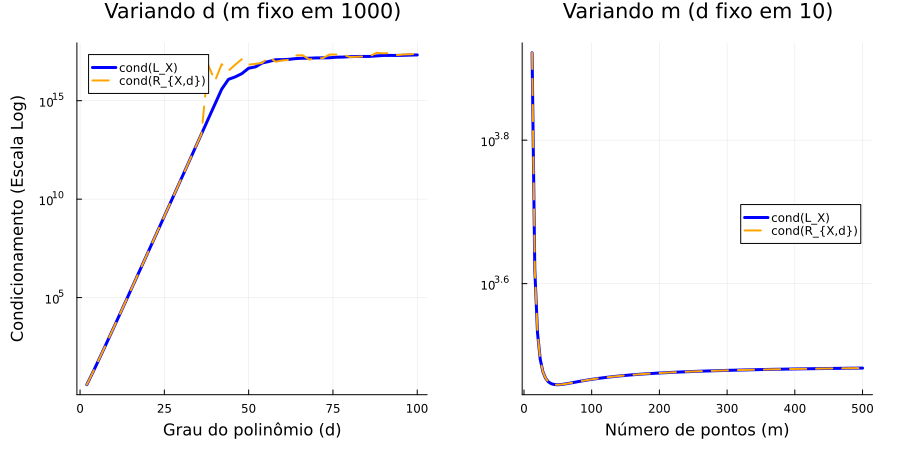

In [42]:
using LinearAlgebra
using Plots

function vandermonde(x::Vector{Float64}, d::Integer)
    m = length(x)
    V = zeros(Float64, m, d + 1)
    for i in 1:m, j in 1:d + 1
        V[i, j] = x[i]^(j - 1)
    end
    return V
end

# ================= Configurações ================= #
# Cenário 1: Fixa m, varia d (mostra a explosão do condicionamento)
m_fixed = 1000
d_vals = 2:2:100

# Cenário 2: Fixa d, varia m (mostra o comportamento com o aumento de pontos)
d_fixed = 10
m_vals = 12:4:500

cond_L_d = zeros(length(d_vals))
cond_R_d = zeros(length(d_vals))

cond_L_m = zeros(length(m_vals))
cond_R_m = zeros(length(m_vals))

# ================= Execução ================= #
# Teste 1: Variando d
for (i, d) in enumerate(d_vals)
    X = collect(range(-1.0, 1.0, length=m_fixed))
    L = vandermonde(X, d)
    R = pinv(L) # inv(transpose(L) * L) * transpose(L)
    
    cond_L_d[i] = cond(L)
    cond_R_d[i] = cond(R)
end

# Teste 2: Variando m
for (i, m) in enumerate(m_vals)
    X = collect(range(-1.0, 1.0, length=m))
    L = vandermonde(X, d_fixed)
    R = pinv(L) # inv(transpose(L) * L) * transpose(L)
    
    cond_L_m[i] = cond(L)
    cond_R_m[i] = cond(R)
end

# ================= Plotagem ================= #
# Gráfico 1
p1 = plot(d_vals, cond_L_d, 
          label="cond(L_X)", 
          lw=3, color=:blue)
plot!(p1, d_vals, cond_R_d, 
      label="cond(R_{X,d})", 
      lw=2, ls=:dash, color=:orange)
plot!(p1, 
      yscale=:log10, 
      title="Variando d (m fixo em $m_fixed)", 
      xlabel="Grau do polinômio (d)", 
      ylabel="Condicionamento (Escala Log)", 
      legend=:topleft,
      grid=true)

# Gráfico 2
p2 = plot(m_vals, cond_L_m, 
          label="cond(L_X)", 
          lw=3, color=:blue)
plot!(p2, m_vals, cond_R_m, 
      label="cond(R_{X,d})", 
      lw=2, ls=:dash, color=:orange)
plot!(p2, 
      yscale=:log10, 
      title="Variando m (d fixo em $d_fixed)", 
      xlabel="Número de pontos (m)", 
      legend=:right,
      grid=true)

# Exibe os dois gráficos lado a lado
plot(p1, p2, layout=(1, 2), size=(900, 450), margin=5Plots.mm)

### (e) Condicionamento de $L_X$ e $R_{X,d}$ na base de Lagrange

**Análise da Estrutura:**

Na base dos polinômios interpoladores de Lagrange, a construção garante que $p_j(x_i) = \delta_{ij}$ nos nós fixados.

Caso $m = d+1$: Os pontos de avaliação coincidem perfeitamente com os nós da base. A avaliação gera exclusivamente zeros e uns, logo $L_X = I_{d+1}$. Como a matriz de regressão atua como a inversa, temos $R_{X,d} = I_{d+1}^{-1} = I_{d+1}$, pois a inversa da identidade é a identidade.

Caso $m > d+1$: A matriz $L_X$ conterá uma submatriz identidade $I_{d+1}$ embutida (correspondente aos nós fixados) e $m - (d+1)$ linhas adicionais com as avaliações numéricas nos pontos excedentes. E $R_{X,d}$ é calculada numericamente via pseudo-inversa.

**Análise do Condicionamento ($\kappa$):**

Caso $m = d+1$: Como ambas as matrizes são a Identidade, o maior e o menor valor singular são iguais a 1 ($\sigma_{max} = \sigma_{min} = 1$). O condicionamento é perfeito: $\kappa(L_X) = \kappa(R_{X,d}) = 1$.

Caso $m > d+1$: O condicionamento será superior a 1, mas ele fica estabilizado e não explode. Isso acontece por que, diferente dos monômios da base canônica (que geram valores muito próximos para valores pequenos em monômios de grau alto, gerando colunas quase linearmente dependentes, exemplo: $(0.01)^9 \approx (0.01)^{10}$ para valores nas bordas $(0.99)^9 \approx (0.99)^{10}$), os polinômios de Lagrange têm a independência linear das colunas bem definida pelo delta de Kronecker. Isso preserva a forte independência linear das colunas de $L_X$, impedindo que o menor valor singular colapse para zero e barrando a explosão exponencial do erro.


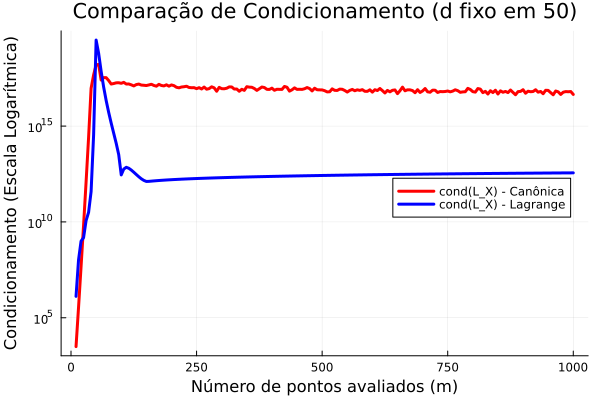

In [47]:
d_fixed = 50
m_vals = 10:5:1000

cond_L_can = zeros(length(m_vals))
cond_L_lag = zeros(length(m_vals))

for (i, m) in enumerate(m_vals)
    X = collect(range(-1.0, 1.0, length=m))
    
    # Nós para Lagrange sempre precisam ser d+1
    nodes = collect(range(-1.0, 1.0, length=d_fixed + 1))
    
    # Construção usando as suas funções
    L_can = vandermonde(X, d_fixed)
    L_lag = lagrange_eval_matrix(X, nodes)
    
    # Armazenando o condicionamento
    cond_L_can[i] = cond(L_can)
    cond_L_lag[i] = cond(L_lag)
end

# ================= Plotagem ================= #

plt = plot(m_vals, cond_L_can, 
          label="cond(L_X) - Canônica", 
          lw=3, color=:red, yscale=:log10)

plot!(plt, m_vals, cond_L_lag, 
      label="cond(L_X) - Lagrange", 
      lw=3, color=:blue)

plot!(plt, 
      title="Comparação de Condicionamento (d fixo em $d_fixed)", 
      xlabel="Número de pontos avaliados (m)", 
      ylabel="Condicionamento (Escala Logarítmica)", 
      legend=:right,
      grid=true)

display(plt)

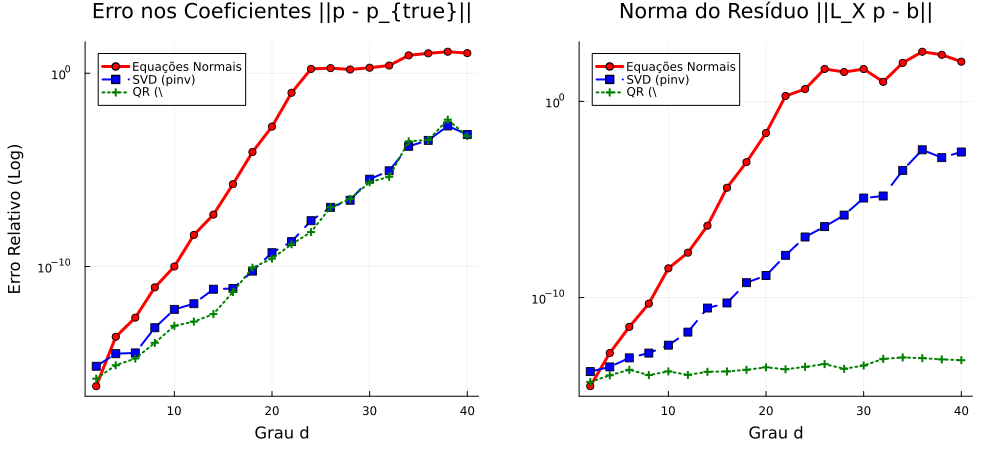

In [52]:
using LinearAlgebra
using Plots

function vandermonde(x::Vector{Float64}, d::Integer)
    m = length(x)
    V = zeros(Float64, m, d + 1)
    for i in 1:m, j in 1:d + 1
        V[i, j] = x[i]^(j - 1)
    end
    return V
end

# Configurações do teste
m = 500
d_vals = 2:2:40

# Arrays para armazenar os erros relativos dos coeficientes ||p - p_true||
err_p_normal = zeros(length(d_vals))
err_p_pinv = zeros(length(d_vals))
err_p_qr = zeros(length(d_vals))

# Arrays para armazenar a norma do resíduo ||L*p - b||
res_normal = zeros(length(d_vals))
res_pinv = zeros(length(d_vals))
res_qr = zeros(length(d_vals))

for (i, d) in enumerate(d_vals)
    X = collect(range(-1.0, 1.0, length=m))
    L = vandermonde(X, d)
    
    # Criamos um polinômio verdadeiro com coeficientes arbitrários (ex: todos 1)
    p_true = ones(d + 1)
    
    # Geramos o vetor b exato
    b = L * p_true
    
    # Método 1: Equações Normais "Na Mão"
    # p = (L^T L)^-1 L^T b
    p_normal = inv(L' * L) * (L' * b)
    
    # Método 2: Decomposição SVD
    p_pinv = pinv(L) * b
    
    # Método 3: Fatoração QR (O operador \ do Julia usa QR para matrizes retangulares)
    p_qr = L \ b
    
    # 1. Calculando o erro nos coeficientes
    err_p_normal[i] = norm(p_normal - p_true) / norm(p_true)
    err_p_pinv[i]   = norm(p_pinv - p_true) / norm(p_true)
    err_p_qr[i]     = norm(p_qr - p_true) / norm(p_true)
    
    # 2. Calculando a norma do resíduo
    res_normal[i] = norm(L * p_normal - b)
    res_pinv[i]   = norm(L * p_pinv - b)
    res_qr[i]     = norm(L * p_qr - b)
end

# ================= Plotagem ================= #
# Gráfico 1: Erro nos coeficientes (O desastre real)
p1 = plot(d_vals, err_p_normal, label="Equações Normais", lw=3, marker=:circle, color=:red)
plot!(p1, d_vals, err_p_pinv, label="SVD (pinv)", lw=2, marker=:square, ls=:dash, color=:blue)
plot!(p1, d_vals, err_p_qr, label="QR (\\)", lw=2, marker=:cross, ls=:dot, color=:green)
plot!(p1, yscale=:log10, title="Erro nos Coeficientes ||p - p_{true}||", 
      xlabel="Grau d", ylabel="Erro Relativo (Log)", legend=:topleft, grid=true)

# Gráfico 2: Norma do Resíduo (A falsa sensação de acerto)
p2 = plot(d_vals, res_normal, label="Equações Normais", lw=3, marker=:circle, color=:red)
plot!(p2, d_vals, res_pinv, label="SVD (pinv)", lw=2, marker=:square, ls=:dash, color=:blue)
plot!(p2, d_vals, res_qr, label="QR (\\)", lw=2, marker=:cross, ls=:dot, color=:green)
plot!(p2, yscale=:log10, title="Norma do Resíduo ||L_X p - b||", 
      xlabel="Grau d", legend=:topleft, grid=true)

plot(p1, p2, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

#### (f) Comparação entre complexidade computacional e condicionamento

Aqui, temos que fazer referência à questão 1 item **g** para contextualizar sobre um conceito que usamos para chegar no resultado que chegamos.

No caso $m > d+1$ (pois $m=d+1$ é trivial), a construção ingênua da matriz $L_X$ na base de Lagrange possui custo $O(md^2)$, mesmo reutilizando os cálculos do denominador dos produtórios. Em contraste, a matriz de Vandermonde na base canônica pode ser construída em $O(md)$.

Entretanto, existe uma forma mais eficiente de avaliar os polinômios de Lagrange, chamada forma baricêntrica.

Definimos inicialmente o polinômio nodal:
$$
\ell(x)=\prod_{k=1}^{d+1}(x-x_k).
$$

A fórmula clássica dos polinômios de Lagrange é
$$
p_j(x)=\prod_{\substack{k=1\\k\neq j}}^{d+1}\frac{x-x_k}{x_j-x_k}.
$$

O numerador pode ser escrito como
$$
\frac{\ell(x)}{x-x_j},
$$
pois $\ell(x)$ contém todos os fatores $(x-x_k)$, incluindo apenas um fator extra $(x-x_j)$.

Como o denominador depende apenas dos nós $x_k$, definimos os pesos baricêntricos
$$
w_j=\frac{1}{\displaystyle\prod_{\substack{k=1\\k\neq j}}^{d+1}(x_j-x_k)}.
$$

Assim,
$$
p_j(x)=\ell(x)\frac{w_j}{x-x_j}.
$$

A construção da matriz passa então a ter duas etapas.

Na primeira, calculam-se os pesos $w_j$. Como existem $d+1$ pesos e cada um exige um produtório de tamanho $d$, o custo é
$$
O(d^2).
$$

Essa etapa é feita apenas uma vez.

Na segunda etapa, para cada ponto $x_i$, calcula-se primeiro $\ell(x_i)$, com custo $O(d)$. Depois, cada entrada $p_j(x_i)$ é obtida em tempo $O(1)$, pois $w_j$ já está pré-calculado.

Logo, o custo para preencher uma linha inteira da matriz é $O(d)$, e o custo total da etapa dinâmica é
$$
O(md).
$$

Portanto, o custo total da construção é
$$
O(d^2+md).
$$

Como no problema de mínimos quadrados vale $m\ge d+1$, o termo dominante é $O(md)$. Assim, a construção da matriz $L_X$ na base de Lagrange possui a mesma complexidade assintótica da matriz de Vandermonde, mas com condicionamento numérico significativamente melhor.

###########################################################################################################
\=============================================================================================
###########################################################################################################

# Questão 3

### (a)

Para todo $q \in \mathcal{P}d$, existe $b = L_X(q) \in \mathbb{R}^m$ tal que $R{X,d}(b) = q$. Isso significa que a transformação $R_{X,d}$ é sobrejetora em relação a $\mathcal{P}_d$, ou seja, a sua imagem é o próprio espaço $\mathcal{P}_d$.

Assim, para encontrar a imagem da transformação composta, basta considerarmos o posto de $L_Y$ atuando sobre todo o domínio $\mathcal{P}_d$. Nesse caso, recaímos na questão 1(d), mas agora avaliando $n$ pontos (do conjunto $Y$) sobre o espaço $\mathcal{P}_d$ de dimensão $d+1$.

Como visto anteriormente, o posto do funcional de avaliação é o mínimo entre o número de pontos de avaliação e a dimensão do espaço de polinômios. Logo, o posto da composta é:
$$\text{rank}(L_Y \circ R_{X,d}) = \text{rank}(L_Y) = \min\{n, d+1\}$$

### (b)

##### Argumento geométrico
Pensando intuitivamente na geometria do problema, a base escolhida para $\mathcal{P}_d$ não afeta o resultado da aplicação composta porque o polinômio atua apenas como uma curva determinada no espaço e intermediária para o ajuste em $X$ e a avaliação em $Y$. Dado um vetor $b \in \mathbb{R}^m$, existe um único polinômio $p \in \mathcal{P}_d$ que melhor se ajusta aos pontos de $X$, como provado anteriormente pela injetividade de  $L_X$ para $m \ge d+1$, o que assegura uma única solução para o problema de mínimos quadrados. Em seguida, $L_Y$ simplesmente avalia essa mesma curva $p$ num novo conjunto de dados. Como a curva geométrica no espaço é determinada de modo único pelas posições dos pontos de $X$ e do vetor $b$, a sua altura nos pontos de $Y$ será estritamente a mesma, independentemente da base que utilizarmos para escrevê-la algebricamente.

##### Resolução matricial

Considere $A_{X,d}$ a matriz de $R_{X,d}$ e $V_Y$ a matriz de $L_Y$ na base canônica de $\mathcal{P}d$. A operação composta $L_Y \circ R{X,d}$ no modo matricial é expressa por $V_Y A_{X,d}$.Considere agora que utilizamos uma nova base $\beta$ para $\mathcal{P}d$ e seja $M$ a matriz de conversão da base canônica para a base $\beta$ (consequentemente, $M^{-1}$ converte da base $\beta$ para a base canônica).Desse modo, $R{X,d}$ deve receber um vetor de $\mathbb{R}^m$ e retornar as coordenadas de um polinômio de $\mathcal{P}d$ na base $\beta$. A matriz dessa operação pode ser expressa por $M A{X,d}$.Por outro lado, $L_Y$ deve receber as coordenadas de um polinômio na base $\beta$ e retornar um vetor de $\mathbb{R}^n$. A matriz dessa operação pode ser expressa por $V_Y M^{-1}$, ou seja, primeiro reconvertemos para a base canônica e depois avaliamos normalmente em $Y$.Desse modo, a aplicação composta dessas operações na base $\beta$ é dada de modo matricial por:$$V_Y M^{-1} M A_{X,d} = V_Y A_{X,d}$$Portanto, a base escolhida para $\mathcal{P}d$ não afeta os resultados da aplicação composta $L_Y \circ R{X,d}$.

### (c)

A composta $L_Y \circ R_{X,d}$ é uma interpolação no sentido de que ela encontra o polinômio que melhor se ajusta a um conjunto de dados e avalia-o num novo conjunto de dados, mas pertencente ao mesmo domínio dos dados originais. Isso ocorre do seguinte modo: primeiro, $R_{X,d}$ obtém o polinômio que melhor se ajusta aos dados de $X$ no sentido de mínimos quadrados. Em seguida, $L_Y$ avalia esse polinômio num conjunto de dados $Y$ que pertence ao mesmo domínio $[-1, 1]$ de $X$, o que caracteriza uma aplicação de interpolação.

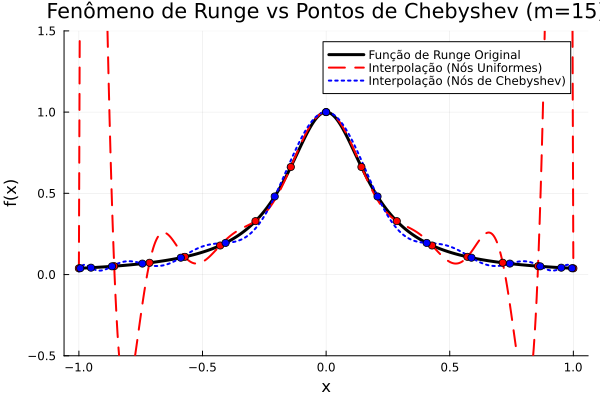

In [16]:
using Plots

# Função original (Função de Runge)
f(x) = 1.0 / (1.0 + 25.0 * x^2)

# Pontos de Chebyshev conforme definido na Questão 3(f)
function chebyshev_nodes(m)
    return [cos(((2i - 1) / (2m)) * π) for i in 1:m]
end

# Avaliação otimizada em O(md) usando a primeira forma baricêntrica
function barycentric_interpolate(nodes, f_nodes, x_eval)
    m = length(nodes)
    
    # 1. Pré-cálculo dos pesos baricêntricos: O(m^2)
    w = zeros(m)
    for j in 1:m
        w[j] = 1.0 / prod(nodes[j] - nodes[k] for k in 1:m if k != j)
    end
    
    # 2 e 3. Avaliação rápida para cada ponto x: O(m) por ponto
    y_eval = zeros(length(x_eval))
    for (i, x) in enumerate(x_eval)
        idx = findfirst(==(x), nodes)
        if !isnothing(idx)
            y_eval[i] = f_nodes[idx] # Evita divisão por zero se x for exatamente um nó
        else
            num = sum(w[j] * f_nodes[j] / (x - nodes[j]) for j in 1:m)
            den = sum(w[j] / (x - nodes[j]) for j in 1:m)
            y_eval[i] = num / den
        end
    end
    return y_eval
end

# ================= Execução do Teste ================= #

m = 15 # m pontos (equivale a um polinômio de grau d = 14)
x_dense = collect(range(-1.0, 1.0, length=500))
y_true = f.(x_dense)

# Caso 1: Nós Uniformemente Espaçados
nodes_uni = collect(range(-1.0, 1.0, length=m))
y_uni = barycentric_interpolate(nodes_uni, f.(nodes_uni), x_dense)

# Caso 2: Nós de Chebyshev
nodes_cheb = chebyshev_nodes(m)
y_cheb = barycentric_interpolate(nodes_cheb, f.(nodes_cheb), x_dense)

# Plotagem dos resultados
plt = plot(x_dense, y_true, label="Função de Runge Original", lw=3, color=:black)
plot!(plt, x_dense, y_uni, label="Interpolação (Nós Uniformes)", lw=2, ls=:dash, color=:red)
plot!(plt, x_dense, y_cheb, label="Interpolação (Nós de Chebyshev)", lw=2, ls=:dot, color=:blue)

scatter!(plt, nodes_uni, f.(nodes_uni), color=:red, label="", ms=4)
scatter!(plt, nodes_cheb, f.(nodes_cheb), color=:blue, label="", ms=4)

ylims!(plt, -0.5, 1.5)
title!(plt, "Fenômeno de Runge vs Pontos de Chebyshev (m=$m)")
xlabel!(plt, "x")
ylabel!(plt, "f(x)")

display(plt)